In [15]:
import pandas as pd
import os
from tqdm import tqdm

from folde.data import DMS_METADATA_FILE, DMS_DIR

raw_dms_metadata = pd.read_csv(DMS_METADATA_FILE)


In [16]:

# Get percentiles of activity distribution, including "one round" activity
# (best activity discovered after one random round of screening), N round
# activity (best activity discovered after N random rounds of screening).

dms_metadata = raw_dms_metadata.copy()
ROUND_SIZE = 16
N_ROUNDS = 10

min_activity_list = []
max_activity_list = []
one_round_activity_list = []
n_round_activity_list = []

for _, row in tqdm(dms_metadata.iterrows(), total=len(dms_metadata)):
    dms_id = row["DMS_id"]
    dms_file_path = os.path.join(DMS_DIR, f"{dms_id}.csv")
    dms_df = pd.read_csv(dms_file_path)

    one_round_quantile = ROUND_SIZE / (ROUND_SIZE + 1)
    n_round_quantile = (N_ROUNDS * ROUND_SIZE) / (N_ROUNDS * ROUND_SIZE + 1)

    min_activity_list.append(dms_df["DMS_score"].min())
    max_activity_list.append(dms_df["DMS_score"].max())
    one_round_activity_list.append(dms_df["DMS_score"].quantile(one_round_quantile))
    n_round_activity_list.append(dms_df["DMS_score"].quantile(n_round_quantile))

dms_metadata["min_activity"] = min_activity_list
dms_metadata["max_activity"] = max_activity_list
dms_metadata["one_round_activity"] = one_round_activity_list
dms_metadata["n_round_activity"] = n_round_activity_list



  0%|          | 0/217 [00:00<?, ?it/s]

100%|██████████| 217/217 [00:11<00:00, 18.83it/s]


In [17]:
dms_metadata

,DMS_id,DMS_filename,UniProt_ID,taxon,source_organism,target_seq,seq_len,includes_multiple_mutants,DMS_total_number_mutants,DMS_number_single_mutants,...,weight_file_name,pdb_file,pdb_range,ProteinGym_version,raw_mut_offset,coarse_selection_type,min_activity,max_activity,one_round_activity,n_round_activity
0,A0A140D2T1_ZIKV_Sourisseau_2019,A0A140D2T1_ZIKV_Sourisseau_2019.csv,A0A140D2T1_ZIKV,Virus,Zika virus (ZIKV),MKNPKKKSGGFRIVNMLKRGVARVNPLGGLKRLPAGLLLGHGPIRM...,3423,False,9576,9576,...,A0A140D2T1_ZIKV_theta_0.01.npy,A0A140D2T1_ZIKV.pdb,291-794,0.1,NaN,OrganismalFitness,0.002354,8.439089,0.699767,2.702880
1,A0A192B1T2_9HIV1_Haddox_2018,A0A192B1T2_9HIV1_Haddox_2018.csv,A0A192B1T2_9HIV1,Virus,Human immunodeficiency virus 1,MRVKGIQMNSQHLLRWGIMILGMIMICSVAGNLWVTVYYGVPVWKD...,852,False,12577,12577,...,A0A192B1T2_9HIV1_theta_0.01.npy,A0A192B1T2_9HIV1.pdb,1-852,0.1,NaN,OrganismalFitness,-10.393382,3.267178,0.463141,1.541082
2,A0A1I9GEU1_NEIME_Kennouche_2019,A0A1I9GEU1_NEIME_Kennouche_2019.csv,A0A1I9GEU1_NEIME,Prokaryote,Neisseria meningitidis,FTLIELMIVIAIVGILAAVALPAYQDYTARAQVSEAILLAEGQKSA...,161,False,922,922,...,A0A1I9GEU1_NEIME_theta_0.2.npy,A0A1I9GEU1_NEIME.pdb,1-161,0.1,NaN,Activity,-8.297000,6.211000,2.129588,3.934416
3,A0A247D711_LISMN_Stadelmann_2021,A0A247D711_LISMN_Stadelmann_2021.csv,A0A247D711_LISMN,Prokaryote,Listeria monocytogenes,MNINDLIREIKNKDYTVKLSGTDSNSITQLIIRVNNDGNEYVISES...,87,False,1653,1653,...,A0A247D711_LISMN_b03_theta_0.2.npy,A0A247D711_LISMN.pdb,1-87,1.0,NaN,Activity,-4.841852,0.959943,0.698217,0.898146
4,A0A2Z5U3Z0_9INFA_Doud_2016,A0A2Z5U3Z0_9INFA_Doud_2016.csv,A0A2Z5U3Z0_9INFA,Virus,Influenza A virus (A/WSN/1933(H1N1)),MKAKLLVLLYAFVATDADTICIGYHANNSTDTVDTILEKNVAVTHS...,565,False,10715,10715,...,A0A2Z5U3Z0_9INFA_theta_0.01.npy,A0A2Z5U3Z0_9INFA.pdb,1-565,0.1,NaN,OrganismalFitness,-4.920219,1.835260,-0.028556,0.802017
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
212,VKOR1_HUMAN_Chiasson_2020_activity,VKOR1_HUMAN_Chiasson_2020_activity.csv,VKOR1_HUMAN,Human,Homo sapiens,MGSTWGSPGWVRLALCLTGLVLSLYALHVKAARARDRDYRALCDVG...,163,False,697,697,...,VKOR1_HUMAN_theta_0.2.npy,VKOR1_HUMAN.pdb,1-163,0.1,NaN,Activity,-1.027708,1.375229,1.223996,1.350408
213,VRPI_BPT7_Tsuboyama_2023_2WNM,VRPI_BPT7_Tsuboyama_2023_2WNM.csv,VRPI_BPT7,Virus,Escherichia phage T7 (Bacteriophage T7),SLSVDNKKFWATVESSEHSFEVPIYAETLDEALELAEWQYVPAGFE...,56,False,1047,1047,...,VRPI_BPT7_theta0.01_2023-08-07_b02.npy,VRPI_BPT7.pdb,1-56,1.0,NaN,Stability,-3.070674,1.169369,0.501038,0.901719
214,YAIA_ECOLI_Tsuboyama_2023_2KVT,YAIA_ECOLI_Tsuboyama_2023_2KVT.csv,YAIA_ECOLI,Prokaryote,Escherichia coli,PREAYIVTIEKGKPGQTVTWYQLRADHPKPDSLISEHPTAQEAMDA...,52,True,1890,928,...,YAIA_ECOLI_theta0.2_2023-08-07_b03.npy,YAIA_ECOLI.pdb,1-52,1.0,NaN,Stability,-5.158251,0.778521,0.046573,0.648338
215,YAP1_HUMAN_Araya_2012,YAP1_HUMAN_Araya_2012.csv,YAP1_HUMAN,Human,Homo sapiens,MDPGQQPPPQPAPQGQGQPPSQPPQGQGPPSGPGQPAPAATQAAPQ...,504,True,10075,362,...,YAP1_HUMAN_theta_0.2.npy,YAP1_HUMAN.pdb,1-504,0.1,NaN,Binding,0.003815,9.835643,2.246224,4.228403


# Find multimutants

In [21]:
dms_metadata.sort_values(by='DMS_number_multiple_mutants', ascending=False)

,DMS_id,DMS_filename,UniProt_ID,taxon,source_organism,target_seq,seq_len,includes_multiple_mutants,DMS_total_number_mutants,DMS_number_single_mutants,...,weight_file_name,pdb_file,pdb_range,ProteinGym_version,raw_mut_offset,coarse_selection_type,min_activity,max_activity,one_round_activity,n_round_activity
181,SPG1_STRSG_Olson_2014,SPG1_STRSG_Olson_2014.csv,SPG1_STRSG,Prokaryote,Streptococcus sp. group G,MEKEKKVKYFLRKSAFGLASVSAAFLVGSTVFAVDSPIEDTPIIRN...,448,True,536962,1045,...,SPG1_STRSG_theta_0.2.npy,SPG1_STRSG.pdb,1-448,0.1,NaN,Binding,-4.605170,3.218876,1.091059,1.811017
73,HIS7_YEAST_Pokusaeva_2019,HIS7_YEAST_Pokusaeva_2019.csv,HIS7_YEAST,Eukaryote,Saccharomyces cerevisiae,MTEQKALVKRITNETKIQIAISLKGGPLAIEHSIFPEKEAEAVAEQ...,220,True,496137,168,...,HIS7_YEAST_theta_0.2.npy,HIS7_YEAST.pdb,1-220,0.1,NaN,OrganismalFitness,0.000000,2.327481,1.062358,1.185580
124,PHOT_CHLRE_Chen_2023,PHOT_CHLRE_Chen_2023.csv,PHOT_CHLRE,Eukaryote,Chlamydomonas reinhardtii,AGLRHTFVVADATLPDCPLVYASEGFYAMTGYGPDEVLGHNARFLQ...,118,True,167529,2122,...,PHOT_CHLRE_theta0.2_2023-08-07_b02.npy,PHOT_CHLRE.pdb,1-118,1.0,NaN,Activity,0.019363,1.780455,1.115667,1.310868
182,SPG1_STRSG_Wu_2016,SPG1_STRSG_Wu_2016.csv,SPG1_STRSG,Prokaryote,Streptococcus sp. group G,MEKEKKVKYFLRKSAFGLASVSAAFLVGSTVFAVDSPIEDTPIIRN...,448,True,149360,76,...,SPG1_STRSG_b01_theta_0.2.npy,SPG1_STRSG.pdb,1-448,1.0,NaN,Binding,0.000000,8.761966,0.212979,2.782827
69,GRB2_HUMAN_Faure_2021,GRB2_HUMAN_Faure_2021.csv,GRB2_HUMAN,Human,Homo sapiens,MEAIAKYDFKATADDELSFKRGDILKVLNEECDQNWYKAELNGKDG...,217,True,63366,1034,...,GRB2_HUMAN_theta_0.2.npy,GRB2_HUMAN.pdb,1-217,0.1,NaN,OrganismalFitness,-1.803398,0.781914,0.058004,0.300325
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31,CAS9_STRP1_Spencer_2017_positive,CAS9_STRP1_Spencer_2017_positive.csv,CAS9_STRP1,Prokaryote,Streptococcus pyogenes,MDKKYSIGLDIGTNSVGWAVITDEYKVPSKKFKVLGNTDRHSIKKN...,1368,False,8117,8117,...,CAS9_STRP1_theta0.2_2023-08-07_b01.npy,CAS9_STRP1.pdb,1-1368,1.0,NaN,Activity,-6.451120,3.915031,0.624864,1.862081
111,OPSD_HUMAN_Wan_2019,OPSD_HUMAN_Wan_2019.csv,OPSD_HUMAN,Human,Homo sapiens,MNGTEGPNFYVPFSNATGVVRSPFEYPQYYLAEPWQFSMLAAYMFL...,348,False,165,165,...,OPSD_HUMAN_theta0.2_2023-10-12_b04.npy,OPSD_HUMAN.pdb,1-348,1.0,NaN,Expression,0.079787,5.561671,4.083958,5.308147
112,OTC_HUMAN_Lo_2023,OTC_HUMAN_Lo_2023.csv,OTC_HUMAN,Human,Homo sapiens,MLFNLRILLNNAAFRNGHNFMVRNFRCGQPLQNKVQLKGRDLLTLK...,354,False,1570,1570,...,OTC_HUMAN_theta0.2_2023-08-07_b02.npy,OTC_HUMAN.pdb,1-354,1.0,NaN,Activity,-0.051000,1.374000,1.063000,1.247547
113,OTU7A_HUMAN_Tsuboyama_2023_2L2D,OTU7A_HUMAN_Tsuboyama_2023_2L2D.csv,OTU7A_HUMAN,Human,Homo sapiens,TLDMDAVLSDFVRSTGAEPGLARDLLEGKNWDLTAALSDYEQ,42,False,635,635,...,OTU7A_HUMAN_theta0.2_2023-08-07_b02.npy,OTU7A_HUMAN.pdb,1-42,1.0,NaN,Stability,-2.727835,1.203736,0.486141,0.942526


In [22]:

dms_file_path = os.path.join(DMS_DIR, f"HIS7_YEAST_Pokusaeva_2019.csv")
dms_df = pd.read_csv(dms_file_path)

In [48]:
from collections import defaultdict

locus_count = defaultdict(int)
mut_count = defaultdict(int)
for mutant in dms_df.mutant:
    mut_count[len(mutant.split(':'))] += 1
    for allele_id in mutant.split(':'):
        locus_count[allele_id[1:-1]] += 1

# locus_count

(217.0, 0.0)

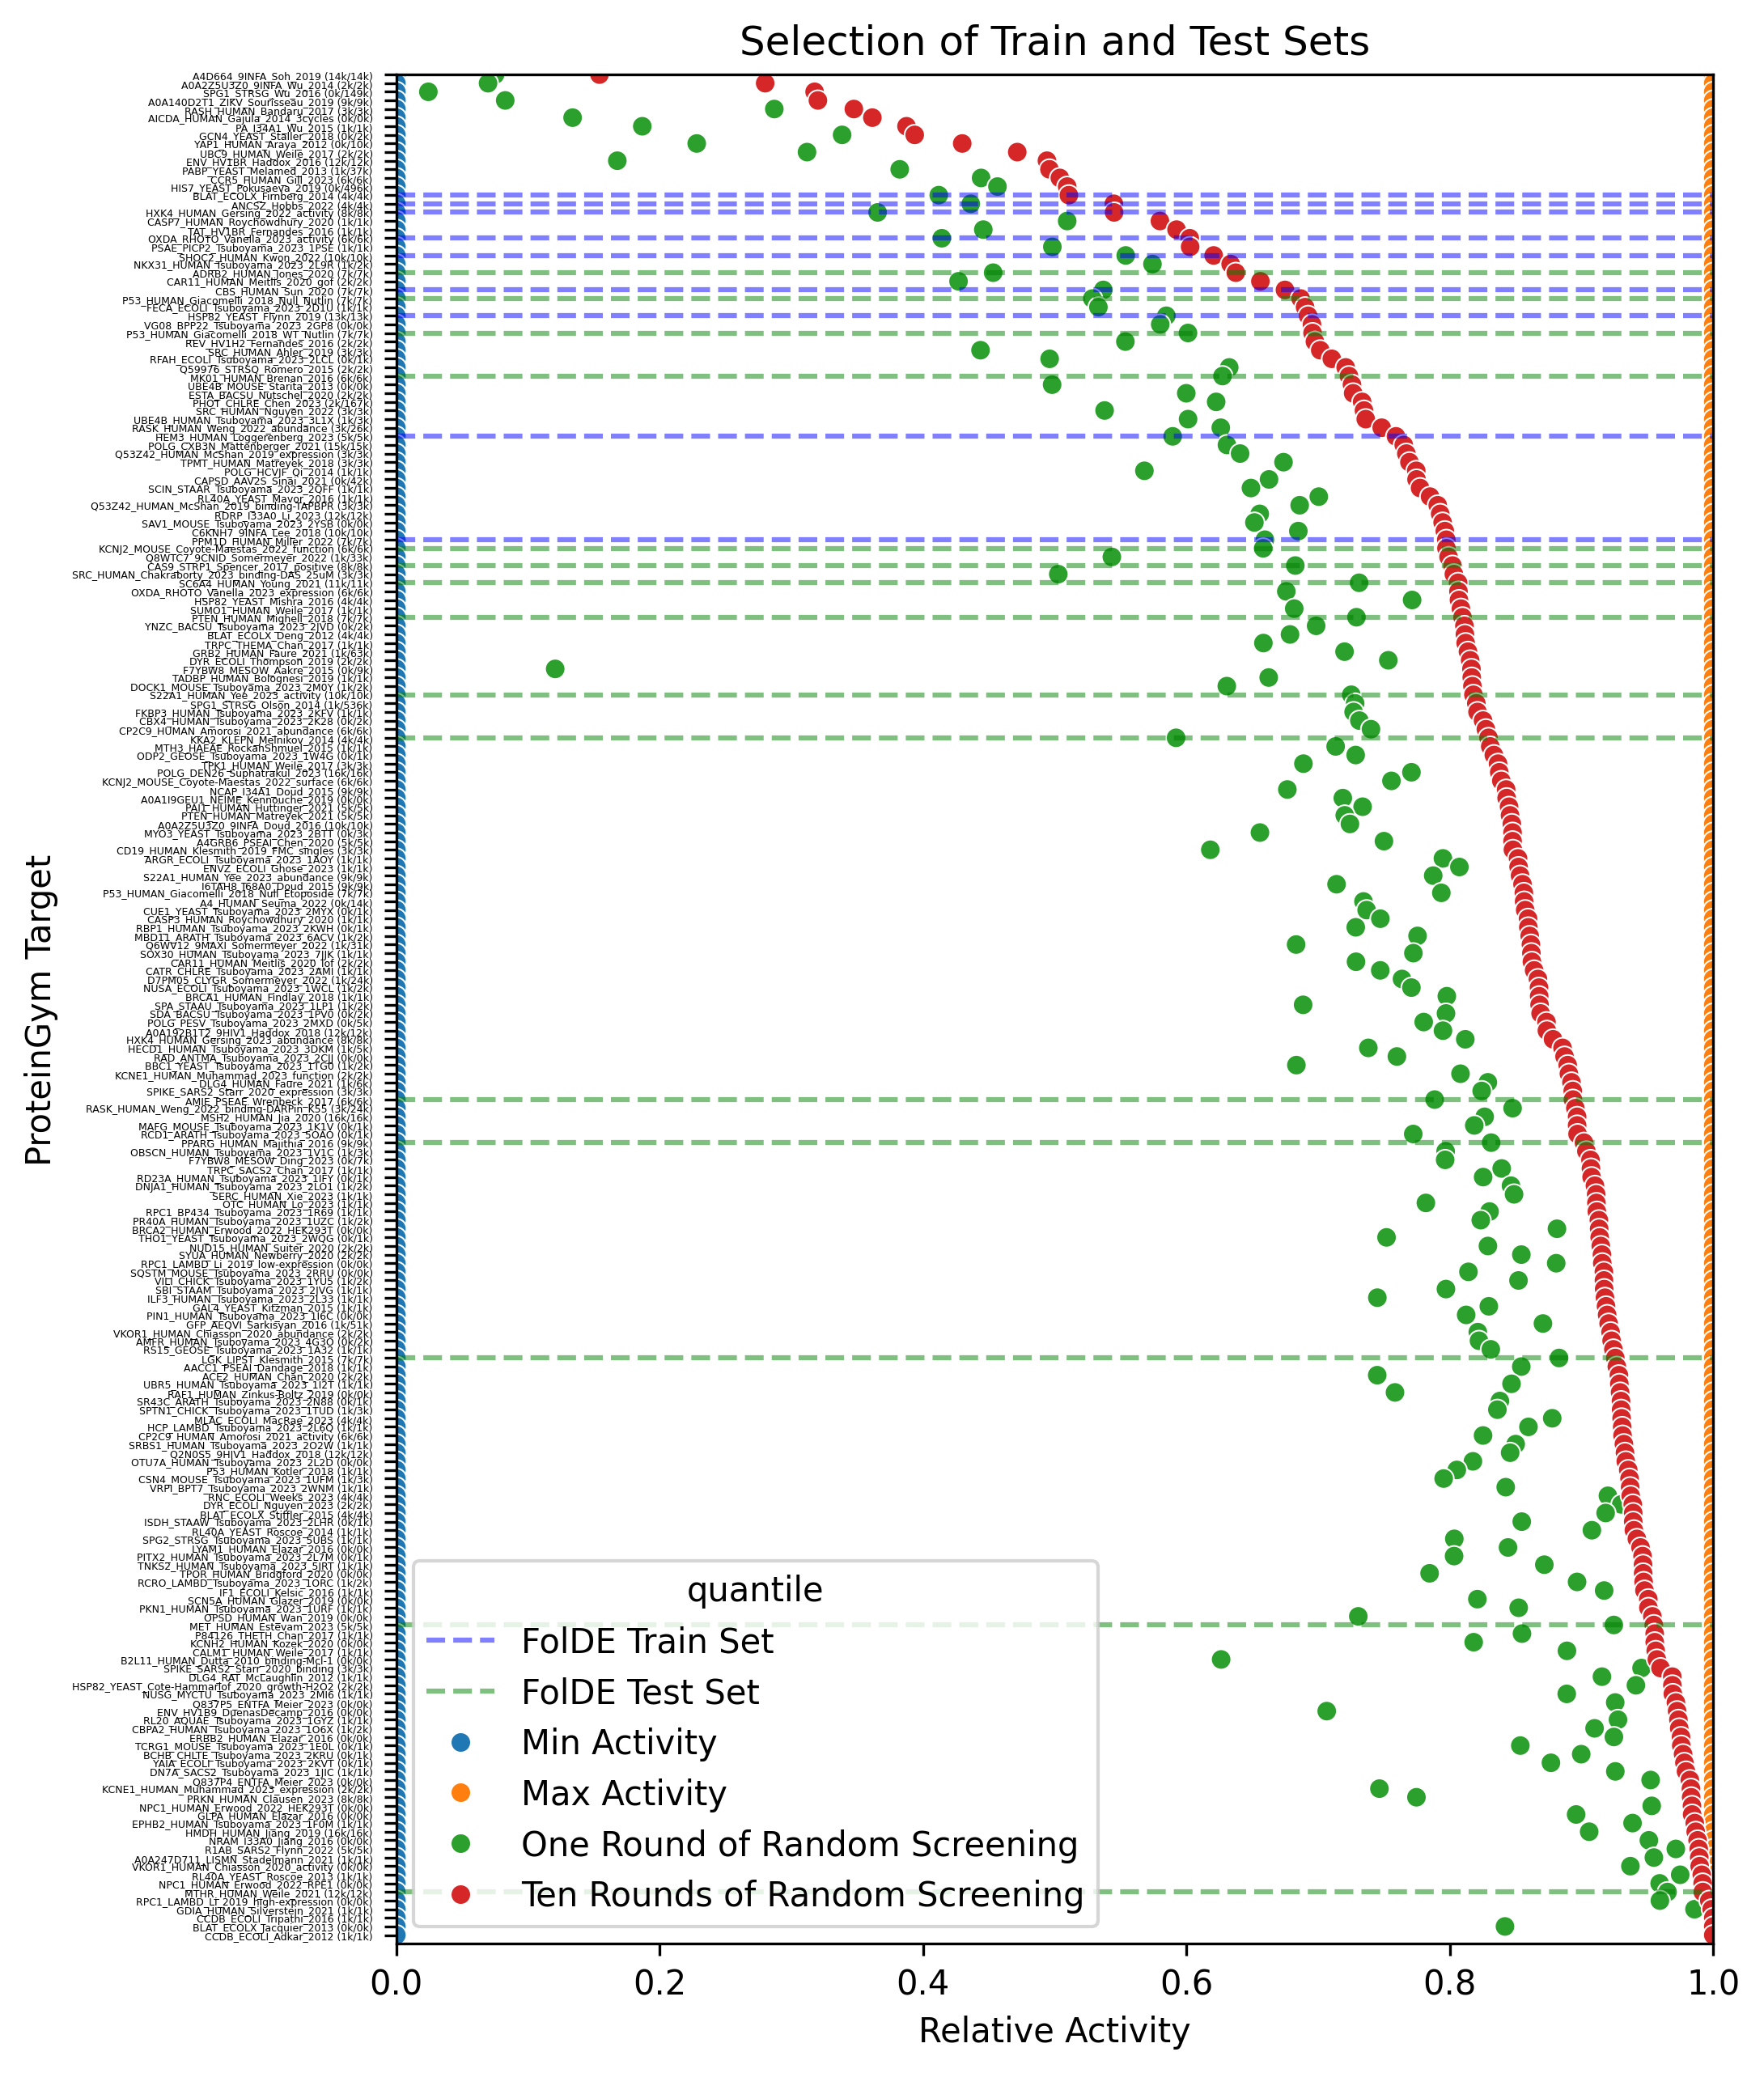

In [ ]:
import seaborn as sns
from matplotlib import pyplot as plt

evolvepro_dms_ids = [
    'A0A140D2T1_ZIKV_Sourisseau_2019',
    'A0A2Z5U3Z0_9INFA_Doud_2016',
    'ADRB2_HUMAN_Jones_2020',
    'BLAT_ECOLX_Stiffler_2015',
    'C6KNH7_9INFA_Lee_2018',
    'IF1_ECOLI_Kelsic_2016',
    'MK01_HUMAN_Brenan_2016',
    'P53_HUMAN_Giacomelli_2018_Null_Etoposide',
    'PHOT_CHLRE_Chen_2023',
]

folde_train_dms_ids = [
    'ANCSZ_Hobbs_2022',
    'BLAT_ECOLX_Firnberg_2014',
    'CBS_HUMAN_Sun_2020',
    'HEM3_HUMAN_Loggerenberg_2023',
    'HSP82_YEAST_Flynn_2019',
    'HXK4_HUMAN_Gersing_2022_activity',
    'OXDA_RHOTO_Vanella_2023_activity',
    'PPM1D_HUMAN_Miller_2022',
    'SHOC2_HUMAN_Kwon_2022',
]

folde_test_dms_ids = [
    'ADRB2_HUMAN_Jones_2020',
    'P53_HUMAN_Giacomelli_2018_Null_Nutlin',
    'P53_HUMAN_Giacomelli_2018_WT_Nutlin',
    'MK01_HUMAN_Brenan_2016',
    'KCNJ2_MOUSE_Coyote-Maestas_2022_function',
    'CAS9_STRP1_Spencer_2017_positive',
    'SC6A4_HUMAN_Young_2021',
    # 'OXDA_RHOTO_Vanella_2023_expression',
    # 'HSP82_YEAST_Mishra_2016',
    'PTEN_HUMAN_Mighell_2018',
    'S22A1_HUMAN_Yee_2023_activity',
    'KKA2_KLEPN_Melnikov_2014',

    # Include some "easy to engineer" targets.
    'PPARG_HUMAN_Majithia_2016',
    # 'P53_HUMAN_Giacomelli_2018_Null_Etoposide',
    'MET_HUMAN_Estevam_2023',
    'MTHR_HUMAN_Weile_2021',
    'LGK_LIPST_Klesmith_2015',
    'AMIE_PSEAE_Wrenbeck_2017',
]

plt.figure(figsize=(7, 10), dpi=300)

quantile_df = dms_metadata.copy()
quantile_df['Target Name'] = dms_metadata.apply(
    lambda row: f"{row['DMS_id']} ({int(row['DMS_number_single_mutants']/1000)}k/{int(row['DMS_total_number_mutants']/1000)}k)",
    axis=1
)
# quantile_df['Target Name'] = dms_metadata.DMS_id
quantile_df = quantile_df[["DMS_id", "Target Name", "min_activity", "max_activity", "one_round_activity", "n_round_activity"]].copy()

quantile_df = quantile_df.set_index(["DMS_id", "Target Name"])
quantile_df = quantile_df\
    .sub(quantile_df.min_activity, axis=0)\
    .div(quantile_df.max_activity - quantile_df.min_activity, axis=0)

quantile_df = quantile_df.reset_index(drop=False) \
    .sort_values(by='n_round_activity')

plot_df = quantile_df.copy()
plot_df.rename(columns={
    'n_round_activity': 'Ten Rounds of Random Screening',
    'one_round_activity': 'One Round of Random Screening',
    'min_activity': 'Min Activity',
    'max_activity': 'Max Activity',
}, inplace=True)
plot_df = plot_df.melt(id_vars=['DMS_id', 'Target Name'], var_name='quantile', value_name='relative_activity')
    # .sort_values(by='one_round_activity') \

# for dms_id in evolvepro_dms_ids:
#     pos = list(melted_quantile_df['DMS_id'].unique()).index(dms_id)
#     plt.axhline(y=pos, color='orange', linestyle='--', alpha=0.5)

for ii, dms_id in enumerate(folde_train_dms_ids):
    pos = list(plot_df['DMS_id'].unique()).index(dms_id)
    kwargs = {}
    if ii == 0:
        kwargs['label'] = 'FolDE Train Set'
    plt.axhline(y=pos, color='blue', linestyle='--', alpha=0.5, **kwargs)

for ii, dms_id in enumerate(folde_test_dms_ids):
    pos = list(plot_df['DMS_id'].unique()).index(dms_id)
    kwargs = {}
    if ii == 0:
        kwargs['label'] = 'FolDE Test Set'
    plt.axhline(y=pos, color='green', linestyle='--', alpha=0.5, **kwargs)

sns.scatterplot(data=plot_df, x='relative_activity', y='Target Name', hue='quantile')
plt.yticks(fontsize=3);
plt.title('Selection of Train and Test Sets')
plt.xlabel('Relative Activity')
plt.ylabel('ProteinGym Target')

plt.xlim(0, 1)
plt.ylim(quantile_df.shape[0], 0)


# for dms_id in evolvepro_dms_ids:
#     x_pos = list(quantile_df['DMS_id'].unique()).index(dms_id)
#     plt.axvline(x=x_pos, color='orange', linestyle='--', alpha=0.5)

# sns.scatterplot(data=quantile_df, x='Target Name', y='relative_activity', hue='quantile')
# plt.xticks(rotation=90, fontsize=3);
# plt.title('Entire activity range')
# quantile_df

In [45]:
quantile_df.n_round_activity

7      0.154210
5      0.280055
182    0.317603
0      0.320091
150    0.347391
         ...   
166    0.996976
66     0.998790
39     1.000000
22     1.000000
38     1.000000
Name: n_round_activity, Length: 217, dtype: float64

In [53]:
merged_df = quantile_df.merge(
    raw_dms_metadata,
    left_on='DMS_id',
    right_on='DMS_id',
    how='left'
)
merged_df['isnt_virus'] = merged_df.taxon != 'Virus'
merged_df['has_enough_singles'] = merged_df.DMS_number_single_mutants > 4000
merged_df['has_enough_total_samples'] = merged_df.DMS_total_number_mutants > 4000
merged_df['is_multimutant'] = merged_df.has_enough_total_samples & (~merged_df.has_enough_singles)
merged_df['is_activity_type'] = ~merged_df.coarse_selection_type.isin(['Binding', 'Expression'])
merged_df['qualifies'] = merged_df.isnt_virus & merged_df.has_enough_singles# & merged_df.is_activity_type

DEBUG_COLS = ['DMS_id', 'qualifies', 'n_round_activity', 'selection_assay', 'coarse_selection_type', 'is_multimutant', 'is_activity_type', 'taxon', 'DMS_number_single_mutants', 'DMS_total_number_mutants']
merged_df[merged_df.DMS_id.isin(evolvepro_dms_ids)][DEBUG_COLS]

,DMS_id,qualifies,n_round_activity,selection_assay,coarse_selection_type,is_multimutant,is_activity_type,taxon,DMS_number_single_mutants,DMS_total_number_mutants
3,A0A140D2T1_ZIKV_Sourisseau_2019,False,0.320091,Viral replication,OrganismalFitness,False,True,Virus,9576,9576
23,ADRB2_HUMAN_Jones_2020,True,0.637411,"transcription (luciferase reporter, isoprotere...",Activity,False,True,Human,7800,7800
35,MK01_HUMAN_Brenan_2016,True,0.723357,Growth,OrganismalFitness,False,True,Human,6809,6809
38,PHOT_CHLRE_Chen_2023,False,0.733355,Fluorescence,Activity,True,True,Eukaryote,2122,167529
53,C6KNH7_9INFA_Lee_2018,False,0.796153,Viral replication,OrganismalFitness,False,True,Virus,10754,10754
87,A0A2Z5U3Z0_9INFA_Doud_2016,False,0.847051,viral replication,OrganismalFitness,False,True,Virus,10715,10715
95,P53_HUMAN_Giacomelli_2018_Null_Etoposide,True,0.856157,"drug resistance (nutlin-3, etoposide)",OrganismalFitness,False,True,Human,7467,7467
167,BLAT_ECOLX_Stiffler_2015,True,0.939190,Growth (10-2500 ug/mL ampicillin),OrganismalFitness,False,True,Prokaryote,4996,4996
176,IF1_ECOLI_Kelsic_2016,False,0.947750,Growth,OrganismalFitness,False,True,Prokaryote,1367,1367


In [54]:
merged_df[(merged_df.qualifies) & (~merged_df.DMS_id.isin(folde_test_dms_ids))][DEBUG_COLS].head(30)
# merged_df[(merged_df.qualifies) & (~merged_df.DMS_id.isin(folde_testing_dms_ids + folde_eval_dms_ids))][DEBUG_COLS].sample(frac=1).head(20)


,DMS_id,qualifies,n_round_activity,selection_assay,coarse_selection_type,is_multimutant,is_activity_type,taxon,DMS_number_single_mutants,DMS_total_number_mutants
12,CCR5_HUMAN_Gill_2023,True,0.503817,"binding affinity, surface expression",Binding,False,False,Human,6137,6137
14,BLAT_ECOLX_Firnberg_2014,True,0.510649,Growth (0.25-1024 ug/mL ampicillin) doubling,OrganismalFitness,False,True,Prokaryote,4783,4783
15,ANCSZ_Hobbs_2022,True,0.544850,successful phosphorylation of bait peptide,Activity,False,True,Eukaryote,4670,4670
16,HXK4_HUMAN_Gersing_2022_activity,True,0.545003,functional complementation to reduced growth o...,OrganismalFitness,False,True,Human,8570,8570
19,OXDA_RHOTO_Vanella_2023_activity,True,0.602452,fluorescent label of enzyme product,Activity,False,True,Eukaryote,6396,6396
21,SHOC2_HUMAN_Kwon_2022,True,0.620615,Drug resistance,OrganismalFitness,False,True,Human,10972,10972
25,CBS_HUMAN_Sun_2020,True,0.674756,Yeast Growth,OrganismalFitness,False,True,Human,7217,7217
28,HSP82_YEAST_Flynn_2019,True,0.692328,"growth, nitrogen depletion (0.0125% ammonium s...",OrganismalFitness,False,True,Eukaryote,13294,13294
42,HEM3_HUMAN_Loggerenberg_2023,True,0.759045,activity,Activity,False,True,Human,5689,5689
54,PPM1D_HUMAN_Miller_2022,True,0.797260,Fitness with GFP reporter,OrganismalFitness,False,True,Human,7889,7889


In [ ]:
folde_eval_dms_ids = [
    'ADRB2_HUMAN_Jones_2020',
    'P53_HUMAN_Giacomelli_2018_Null_Nutlin',
    'P53_HUMAN_Giacomelli_2018_WT_Nutlin',
    'MK01_HUMAN_Brenan_2016',
    'KCNJ2_MOUSE_Coyote-Maestas_2022_function',
    'CAS9_STRP1_Spencer_2017_positive',
    'SC6A4_HUMAN_Young_2021',
    # 'OXDA_RHOTO_Vanella_2023_expression',
    # 'HSP82_YEAST_Mishra_2016',
    'PTEN_HUMAN_Mighell_2018',
    'S22A1_HUMAN_Yee_2023_activity',
    'KKA2_KLEPN_Melnikov_2014',

    # Include some "easy to engineer" targets.
    'PPARG_HUMAN_Majithia_2016',
    # 'P53_HUMAN_Giacomelli_2018_Null_Etoposide',
    'MET_HUMAN_Estevam_2023',
    'MTHR_HUMAN_Weile_2021',
    'LGK_LIPST_Klesmith_2015',
    'AMIE_PSEAE_Wrenbeck_2017',
]
merged_df.set_index('DMS_id', inplace=False).loc[folde_eval_dms_ids].reset_index()[DEBUG_COLS]

# foldy_bulk_input_df = merged_df.set_index('DMS_id', inplace=False).loc[folde_eval_dms_ids].reset_index()[['DMS_id', 'target_seq']].rename(columns={'DMS_id': 'fold_name', 'target_seq': 'chain_1_sequence'})
# foldy_bulk_input_df['chain_1_id'] = 'A'
# foldy_bulk_input_df['chain_1_type'] = 'protein'
# foldy_bulk_input_df.to_csv('notebooks/jacob/folde_eval_bulk_foldy_input.csv', index=False)

# new_benchmark_dms_ids = [
#     'BLAT_ECOLX_Firnberg_2014',
#     'ANCSZ_Hobbs_2022',
#     'HXK4_HUMAN_Gersing_2022_activity',
#     'OXDA_RHOTO_Vanella_2023_activity',
#     'SHOC2_HUMAN_Kwon_2022',
#     'ADRB2_HUMAN_Jones_2020',
#     'CBS_HUMAN_Sun_2020',
#     'P53_HUMAN_Giacomelli_2018_Null_Nutlin',
#     'HSP82_YEAST_Flynn_2019',
#     'P53_HUMAN_Giacomelli_2018_WT_Nutlin',
#     'MK01_HUMAN_Brenan_2016',
#     'HEM3_HUMAN_Loggerenberg_2023',
#     'PPM1D_HUMAN_Miller_2022',
# ]
# for row in merged_df[merged_df.DMS_id.isin(new_benchmark_dms_ids)].itertuples():
#     print(row.DMS_id, row.target_seq)

,DMS_id,qualifies,n_round_activity,selection_assay,coarse_selection_type,is_multimutant,is_activity_type,taxon,DMS_number_single_mutants,DMS_total_number_mutants
0,ADRB2_HUMAN_Jones_2020,True,0.637411,"transcription (luciferase reporter, isoprotere...",Activity,False,True,Human,7800,7800
1,P53_HUMAN_Giacomelli_2018_Null_Nutlin,True,0.686664,"drug resistance (nutlin-3, etoposide)",OrganismalFitness,False,True,Human,7467,7467
2,P53_HUMAN_Giacomelli_2018_WT_Nutlin,True,0.695700,"drug resistance (nutlin-3, etoposide)",OrganismalFitness,False,True,Human,7467,7467
3,MK01_HUMAN_Brenan_2016,True,0.723357,Growth,OrganismalFitness,False,True,Human,6809,6809
4,KCNJ2_MOUSE_Coyote-Maestas_2022_function,True,0.797398,Ion conduction,Activity,False,True,Eukaryote,6963,6963
5,CAS9_STRP1_Spencer_2017_positive,True,0.801956,count of mutation where survival depends on ex...,Activity,False,True,Prokaryote,8117,8117
6,SC6A4_HUMAN_Young_2021,True,0.806222,Fluorescence,Activity,False,True,Human,11576,11576
7,PTEN_HUMAN_Mighell_2018,True,0.809583,growth (surrogate for enzymatic activity/hydro...,Activity,False,True,Human,7260,7260
8,S22A1_HUMAN_Yee_2023_activity,True,0.817875,uptake of cytotoxic substrate,Activity,False,True,Human,10094,10094
9,KKA2_KLEPN_Melnikov_2014,True,0.829306,"Growth (225 ug/mL kanamycin) 1:1, 1:2, 1:4, 1:...",OrganismalFitness,False,True,Prokaryote,4960,4960


In [36]:
merged_df[merged_df.qualifies].iloc[0].head(100)

DMS_id                                                      CCR5_HUMAN_Gill_2023
Target Name                                         CCR5_HUMAN_Gill_2023 (6k/6k)
min_activity                                                                 0.0
max_activity                                                                 1.0
one_round_activity                                                       0.44402
n_round_activity                                                        0.503817
DMS_filename                                            CCR5_HUMAN_Gill_2023.csv
UniProt_ID                                                            CCR5_HUMAN
taxon                                                                      Human
source_organism                                                     Homo sapiens
target_seq                     MDYQVSSPIYDINYYTSEPCQKINVKQIAARLLPPLYSLVFIFGFV...
seq_len                                                                      352
includes_multiple_mutants   

In [58]:
merged_df[merged_df.DMS_id == 'CP2C9_HUMAN_Amorosi_2021_activity'].iloc[0].target_seq

'MDSLVVLVLCLSCLLLLSLWRQSSGRGKLPPGPTPLPVIGNILQIGIKDISKSLTNLSKVYGPVFTLYFGLKPIVVLHGYEAVKEALIDLGEEFSGRGIFPLAERANRGFGIVFSNGKKWKEIRRFSLMTLRNFGMGKRSIEDRVQEEARCLVEELRKTKASPCDPTFILGCAPCNVICSIIFHKRFDYKDQQFLNLMEKLNENIKILSSPWIQICNNFSPIIDYFPGTHNKLLKNVAFMKSYILEKVKEHQESMDMNNPQDFIDCFLMKMEKEKHNQPSEFTIESLENTAVDLFGAGTETTSTTLRYALLLLLKHPEVTAKVQEEIERVIGRNRSPCMQDRSHMPYTDAVVHEVQRYIDLLPTSLPHAVTCDIKFRNYLIPKGTTILISLTSVLHDNKEFPNPEMFDPHHFLDEGGNFKKSKYFMPFSAGKRICVGEALAGMELFLFLTSILQNFNLKSLVDPKNLDTTPVVNGFASVPPFYQLCFIPV'